# Building ML Models with Scikit-learn

**Applied ML in Production · Session 4**

---

You already know these algorithms. Logistic regression, decision trees, random
forests, KNN — you have derived them, plotted them, and been examined on them.

This session is not a second pass over the maths. It is about the thing nobody
teaches explicitly and everybody needs daily: **scikit-learn presents every one of
those algorithms through the same three-method interface**, so swapping one for
another is a one-line change. Once you see that, the question stops being "how
does this algorithm work" and becomes "which one do I choose, and how do I defend
the choice".

We answer both, on the loan problem, in one sitting.

## How to work through this

Type the code. There is very little of it, and the point is the *shape* of the
code — the same four lines appear for every model in the library.

Run each cell, read the output, then read the commentary. If a cell errors, run
from the top.

## Learning objectives

After this session you will be able to:

- State the **estimator contract** — `fit`, `predict`, `transform` — and use it
  on any scikit-learn model without reading its documentation first.
- Tell a **hyperparameter** from a **learned parameter**, and find both on a
  fitted model.
- Swap one estimator for another and compare them fairly on the same split.
- Recognise overfitting from a train-versus-test gap.
- Choose an estimator from the constraints of the problem — data size,
  explainability, latency, feature types — rather than by habit.
- Apply the same contract to a regression problem.
- Compose a scaler and a model into a single object with `make_pipeline`.
- Score a single new applicant and turn the probability into a decision.

## Setup

We reuse session 2's honest feature set: leak removed, missingness flagged.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True, "grid.alpha": 0.3})
pd.set_option("display.width", 120)


def find_data(filename="loan_default.csv"):
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / "data" / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"could not find data/{filename}")


loans = pd.read_csv(find_data(), parse_dates=["application_date"])

features = loans[["loan_amount", "tenure_months", "interest_rate", "previous_loans",
                  "days_past_due_history", "annual_income", "credit_score",
                  "sector", "employment_type", "has_collateral"]].copy()
features["income_missing"] = features["annual_income"].isna().astype(int)
features["score_missing"] = features["credit_score"].isna().astype(int)

X = pd.get_dummies(features, drop_first=True).astype(float)
y = loans["defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
medians = X_train.median()
X_train, X_test = X_train.fillna(medians), X_test.fillna(medians)

scaler = StandardScaler().fit(X_train)
X_train_scaled, X_test_scaled = scaler.transform(X_train), scaler.transform(X_test)

print(f"train {X_train.shape}, test {X_test.shape}")

train (9000, 18), test (3000, 18)


---

## 1. The estimator contract

Every model in scikit-learn is an **estimator**, and every estimator honours the
same contract:

| Method | What it does | Who has it |
|--------|--------------|------------|
| `fit(X, y)` | Learn from data | Every estimator |
| `predict(X)` | Produce a label or a number | Every model |
| `predict_proba(X)` | Produce class probabilities | Most classifiers |
| `transform(X)` | Produce modified data | Scalers, encoders, imputers |
| `score(X, y)` | A default metric, for a quick look | Every model |

That is the whole interface. A scaler is `fit` + `transform`. A classifier is
`fit` + `predict`. Nothing else has to be memorised.

In [2]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")   # not trained yet
model.fit(X_train_scaled, y_train)                                   # now it is

print("predict returns labels:       ", model.predict(X_test_scaled)[:5])
print("predict_proba returns columns:", model.predict_proba(X_test_scaled).shape,
      "-> [P(repaid), P(default)]")
print("probability of default, first five applications:",
      model.predict_proba(X_test_scaled)[:5, 1].round(3))

predict returns labels:        [1 1 0 1 1]
predict_proba returns columns: (3000, 2) -> [P(repaid), P(default)]
probability of default, first five applications: [0.722 0.518 0.398 0.928 0.921]


### Hyperparameters versus learned parameters

Two kinds of number live on a fitted model, and confusing them causes real bugs.

**Hyperparameters** are your choices. You pass them to the constructor, they are
visible before training, and tuning them is session 6.

**Learned parameters** are what `fit` discovered. Scikit-learn marks every one
with a **trailing underscore** — `coef_`, `classes_`, `feature_importances_`.
That underscore is a convention worth knowing: it means "this did not exist until
you called `fit`".

In [3]:
print("hyperparameters you chose:")
print("  class_weight =", model.get_params()["class_weight"])
print("  max_iter     =", model.get_params()["max_iter"])

print("\nlearned parameters (note the trailing underscore):")
print("  classes_ =", model.classes_)
print("  intercept_ =", model.intercept_.round(3))

coefficients = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("\n  three strongest pushes toward 'repaid':")
print(coefficients.head(3).round(3).to_string())
print("\n  three strongest pushes toward 'default':")
print(coefficients.tail(3).round(3).to_string())

hyperparameters you chose:
  class_weight = balanced
  max_iter     = 1000

learned parameters (note the trailing underscore):
  classes_ = [0 1]
  intercept_ = [-0.374]

  three strongest pushes toward 'repaid':
credit_score         -0.337
annual_income        -0.321
has_collateral_Yes   -0.133

  three strongest pushes toward 'default':
days_past_due_history    0.176
loan_amount              0.322
interest_rate            0.612


Read those coefficients as a sentence: a higher credit score pushes toward
repayment, a higher interest rate pushes toward default. The second one is the
lender's own pricing showing up in the data, as we saw in session 3 — predictive,
not causal.

This interpretability is the reason linear models survive in regulated lending
long after fancier options exist. You can hand that table to a credit committee.

---

## 2. Swapping the estimator

Because the contract is identical, comparing five algorithms is a loop. The only
thing that varies is which matrix goes in — scaled or unscaled.

In [4]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

candidates = {
    # name:                     (estimator,                                       needs scaling)
    "logistic regression":      (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "decision tree (depth 5)":  (DecisionTreeClassifier(max_depth=5, class_weight="balanced", random_state=42), False),
    "decision tree (unlimited)": (DecisionTreeClassifier(class_weight="balanced", random_state=42), False),
    "random forest":            (RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42), False),
    "gradient boosting":        (GradientBoostingClassifier(random_state=42), False),
    "k-nearest neighbours":     (KNeighborsClassifier(n_neighbors=25), True),
}

rows = []
for name, (estimator, needs_scaling) in candidates.items():
    train_X = X_train_scaled if needs_scaling else X_train
    test_X = X_test_scaled if needs_scaling else X_test

    estimator.fit(train_X, y_train)          # <- the same line, every time

    rows.append({
        "model": name,
        "train AUC": roc_auc_score(y_train, estimator.predict_proba(train_X)[:, 1]),
        "test AUC": roc_auc_score(y_test, estimator.predict_proba(test_X)[:, 1]),
    })

comparison = pd.DataFrame(rows).set_index("model").round(3)
comparison["gap"] = (comparison["train AUC"] - comparison["test AUC"]).round(3)
print(comparison.to_string())

                           train AUC  test AUC    gap
model                                                
logistic regression            0.769     0.782 -0.013
decision tree (depth 5)        0.783     0.735  0.048
decision tree (unlimited)      1.000     0.560  0.440
random forest                  1.000     0.763  0.237
gradient boosting              0.822     0.772  0.050
k-nearest neighbours           0.796     0.711  0.085


Four things in that table are worth more than the winner.

**The simplest model wins.** Logistic regression, at 0.782, beats every ensemble
here. That is common on small, tidy, mostly-linear tabular data and it surprises
students every year. Complexity is a cost you pay when the data demands it.

**The unlimited tree memorised the training set.** Train AUC 1.000, test AUC
0.560 — barely better than guessing. It learned 9,000 individual applications
rather than the pattern behind them. This is **overfitting** in its purest form,
and the `gap` column is how you spot it.

**The random forest also has a train AUC of 1.000 — and still generalises.**
Averaging hundreds of overfitted trees cancels most of their individual errors.
A large gap is a warning sign, not a verdict; read it together with the test score.

**Scaling changed nothing for the trees.** They split on order, and order survives
rescaling. It matters enormously for logistic regression and KNN, which measure
distances and gradients.

One detail that confuses people every year: logistic regression's gap is slightly
*negative* — it scored a shade higher on test than on train. That is not a
miracle, it is the luck of one particular split. Gaps of a hundredth or two in
either direction are noise; gaps of 0.4, like the unlimited tree's, are not.

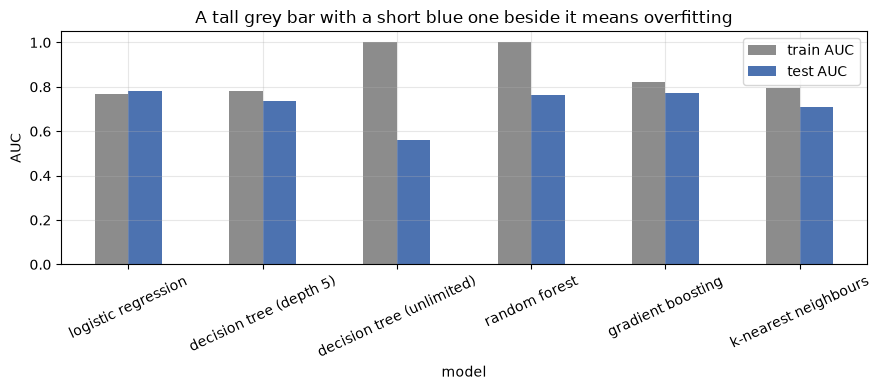

In [5]:
comparison[["train AUC", "test AUC"]].plot.bar(rot=25, color=["#8C8C8C", "#4C72B0"])
plt.ylabel("AUC")
plt.title("A tall grey bar with a short blue one beside it means overfitting")
plt.tight_layout()
plt.show()

---

## 3. What actually changes when you swap

The line of code is identical. Everything around it is not.

| | Logistic regression | Decision tree | Random forest / boosting | KNN |
|---|---|---|---|---|
| **Needs scaling** | Yes | No | No | Yes |
| **Handles non-linearity** | Only if you build it (session 3) | Yes | Yes | Yes |
| **Explainable** | Coefficients, one per feature | The tree itself, if shallow | Importances only | Barely |
| **Training cost** | Very low | Very low | Moderate to high | None — it defers the work |
| **Prediction cost** | Very low | Very low | Moderate | High: compares to every training row |
| **Key hyperparameters** | `C`, `penalty`, `class_weight` | `max_depth`, `min_samples_leaf` | `n_estimators`, `max_depth`, `learning_rate` | `n_neighbors`, `metric` |
| **Main failure mode** | Underfits curved patterns | Overfits without a depth limit | Slow, opaque | Falls apart in high dimensions |

Two practical notes that cost teams real time:

**Prediction cost is a deployment constraint, not a detail.** KNN stores the
training set and compares against it at prediction time — fine in a notebook,
awkward in a service that must answer in milliseconds.

**Randomness needs pinning.** Trees, forests, and boosting sample. Without
`random_state`, two runs give two different models, and you cannot tell a real
improvement from noise. Set it everywhere, always.

---

## 4. Choosing an estimator

There is no best algorithm. There is a best algorithm *for a set of constraints*,
and the constraints come from the charter you wrote in session 1.

| If the project needs... | Start with |
|---|---|
| Explainable decisions, regulated setting | Logistic regression, or a shallow tree |
| Strong accuracy on tabular data, explainability secondary | Gradient boosting (XGBoost, LightGBM, `HistGradientBoosting`) |
| A baseline in five minutes | Logistic regression |
| Predictions in microseconds | Linear model |
| Mixed categorical and numeric, minimal preprocessing | Tree ensembles |
| Very little data (hundreds of rows) | Linear or a shallow tree; ensembles will overfit |

**The working rule: start with the simplest thing that could work, measure it,
and only add complexity when the measurement demands it.** A gradient boosting
model that beats logistic regression by 0.004 AUC is not worth the deployment
weight, the training time, and the explanation you now owe a regulator.

Our charter asks for explainable declines. That plus the table above makes
logistic regression the right choice here — and it also happens to score best.
It will not always be so convenient.

---

## 5. The same contract for regression

Classification predicts a class; regression predicts a number. The code is the
same four lines — only the estimator, and the metrics, change.

Suppose the credit team asks a different question: *"what interest rate would this
application normally be priced at?"* — useful for spotting inconsistent pricing
between branches.

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

rate_features = loans[["loan_amount", "tenure_months", "previous_loans",
                       "days_past_due_history", "credit_score", "annual_income"]]
rate_features = rate_features.fillna(rate_features.median())
rate = loans["interest_rate"]

A_train, A_test, r_train, r_test = train_test_split(
    rate_features, rate, test_size=0.25, random_state=42
)

for name, estimator in [("linear regression", LinearRegression()),
                        ("random forest", RandomForestRegressor(n_estimators=100, random_state=42))]:
    estimator.fit(A_train, r_train)
    predicted = estimator.predict(A_test)
    print(f"{name:<20} MAE {mean_absolute_error(r_test, predicted):.2f} percentage points   "
          f"R² {r2_score(r_test, predicted):.3f}")

linear regression    MAE 0.78 percentage points   R² 0.565


random forest        MAE 0.75 percentage points   R² 0.587


Same `fit`, same `predict`, different metrics. **MAE** says the typical prediction
is off by about 0.8 percentage points of interest; **R²** says the features
explain a bit under 60% of the variation in pricing.

Note there is no `predict_proba` here — a regressor has nothing to be probable
about. That is the only part of the contract that changes.

Sessions 5 and 6 go properly into metrics. For now, the point is that the whole
library works this way: learn the contract once, and every estimator in it,
including ones written years from now, is already familiar.

---

## 6. Composing steps into one object

Session 2 insisted: fit every transformation on the training data only. Doing that
by hand — scaler here, model there, remember the order — is exactly the kind of
discipline that fails at 6pm on a Friday.

`make_pipeline` chains transformers and a final estimator into a **single
estimator** that still honours the contract. One `fit`, one `predict`, and the
scaler can no longer see the test set by accident.

In [7]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, class_weight="balanced"),
)

pipeline.fit(X_train, y_train)          # the scaler is fitted on TRAIN, inside
probabilities = pipeline.predict_proba(X_test)[:, 1]

print(f"pipeline test AUC: {roc_auc_score(y_test, probabilities):.3f}")
print("steps:", [name for name, _ in pipeline.steps])

pipeline test AUC: 0.782
steps: ['standardscaler', 'logisticregression']


The same 0.782, with the leakage risk engineered out rather than remembered.

Session 7 extends this to `ColumnTransformer`, which lets one pipeline apply
different treatment to numeric and categorical columns, and makes the whole
preparation chain a single saveable object.

---

## 7. Making a prediction for one applicant

The end of the line: a real application arrives, and the model has to answer.

In [8]:
applicant = {
    "loan_amount": 800_000,
    "tenure_months": 24,
    "interest_rate": 14.5,
    "previous_loans": 0,
    "days_past_due_history": 30,
    "annual_income": 600_000,
    "credit_score": 545,
    "income_missing": 0,
    "score_missing": 0,
    "sector_Construction": 1,
}

# Build a one-row frame with exactly the training columns; anything unset is 0.
new_application = pd.DataFrame([applicant]).reindex(columns=X_train.columns, fill_value=0)

probability = pipeline.predict_proba(new_application)[0, 1]

THRESHOLD = 0.15        # chosen in session 3, owned by the business
decision = "SEND TO SENIOR REVIEW" if probability >= THRESHOLD else "auto-approve"

print(f"probability of default: {probability:.1%}")
print(f"threshold in force:     {THRESHOLD:.0%}")
print(f"decision:               {decision}")

probability of default: 87.4%
threshold in force:     15%
decision:               SEND TO SENIOR REVIEW


That is the whole product, in three lines: a probability, a threshold, a decision.

Everything else in this module — preparation, features, metrics, tuning,
tracking, serving, monitoring — exists to make those three lines trustworthy.

The `reindex` line matters more than it looks. The model was trained on a fixed
list of columns in a fixed order, and it will happily produce a confident number
from a misaligned row. Session 9 replaces this hand-built frame with a validated
API request that rejects a bad payload instead of scoring it.

---

## Your turn

**1. Add an estimator.** Put `HistGradientBoostingClassifier` and
`GaussianNB` into the `candidates` dictionary and re-run the loop. Do either
beat logistic regression? Which needed scaling?

**2. Close the tree's gap.** The unlimited tree scored 1.000 on train and 0.560
on test. Try `max_depth` of 3, 5, 10 and 20. Plot train and test AUC against
depth. Where do the two lines cross over from underfitting to overfitting?

**3. Break the contract deliberately.** Fit `KNeighborsClassifier` on the
*unscaled* training data and compare its AUC to the scaled version. Explain the
difference in one sentence using what KNN measures.

**4. Read a tree.** Fit `DecisionTreeClassifier(max_depth=3)` and print it with
`sklearn.tree.export_text(tree, feature_names=list(X_train.columns))`. Is the
first split the feature you expected from session 3's importance ranking?

**5. Time it.** Wrap each `fit` in `time.perf_counter()` and add a "seconds"
column to the comparison table. Then time `predict` on the test set. Which model
would you choose if the requirement were 10,000 predictions per second?

**6. Score three applicants.** Change the `applicant` dictionary to describe a
strong applicant, a marginal one, and a weak one. Do the probabilities order the
way a credit officer would expect? If one surprises you, say why.

---

## If you remember nothing else

**One contract, every model.** `fit`, `predict`, `transform`. Learn it once and
the entire library — plus every library that copies its interface — is open to you.

**The trailing underscore means learned.** `coef_`, `classes_`,
`feature_importances_` do not exist until `fit` has run.

**Swapping models is one line, so compare rather than argue.** A loop over a
dictionary settles in seconds what a meeting cannot settle in an hour.

**Start simple.** On tidy tabular data the linear model is frequently the winner,
and it is always the cheapest thing to explain, deploy, and debug.

**A train–test gap is the overfitting alarm.** Train 1.000 with test 0.560 is a
model that memorised; read the two numbers together, never one alone.

**Pipelines make the session 2 rule automatic.** If the scaler lives inside the
pipeline, it cannot see the test set — no discipline required.

---

## Glossary

| Term | Meaning |
|------|---------|
| **Estimator** | Any scikit-learn object with a `fit` method |
| **Transformer** | An estimator with `transform` — scalers, encoders, imputers |
| **Predictor** | An estimator with `predict` — classifiers and regressors |
| **Hyperparameter** | A setting you choose before training, passed to the constructor |
| **Learned parameter** | A value discovered by `fit`, named with a trailing underscore |
| **`predict_proba`** | Class probabilities rather than a hard label |
| **Overfitting** | Strong on training data, weak on unseen data |
| **Underfitting** | Weak on both — the model is too simple for the pattern |
| **Ensemble** | Many models combined — bagging (forests) or boosting |
| **`random_state`** | The seed that makes a randomised fit reproducible |
| **Pipeline** | Transformers plus a final estimator, composed into one estimator |

## Further reading

- scikit-learn User Guide, *Supervised learning* — every estimator, one page each,
  all following the contract above.
- scikit-learn, *Choosing the right estimator* — the official flowchart; useful
  once you can already justify ignoring it.
- Aurélien Géron, *Hands-On Machine Learning*, chapters 2–7 — the same estimators
  worked through in depth.
- Your DCS 404 notebooks — for the derivations behind logistic regression, trees,
  KNN and ensembles, which this session deliberately does not repeat.

---

**Next session:** *Model Evaluation and Performance Metrics* — which number you
report, why accuracy has been lying to us since session 1, and how the cost of
being wrong decides the metric.